In [45]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage,HumanMessage
import os
import operator


In [46]:
load_dotenv()

True

In [47]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

generator_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=GROQ_API_KEY
)

evaluator__llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY
)

optimizer_llm = ChatGroq(
    model="mistral-7b-instruct",
    api_key=GROQ_API_KEY
)

In [48]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")


In [49]:
structured_evaluator_llm = evaluator__llm.with_structured_output(TweetEvaluation)

In [50]:
#state

class TweetState(TypedDict):

    topic:str
    tweet:str
    evaluation: Literal["approved","needs_improvement"]
    feedback:str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]
    

In [51]:
def generate_tweet(state: TweetState):
    #prompt
     messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
     
     #send generator_llm
     response = generator_llm.invoke(messages).content

     return {'tweet':response,'tweet_history':[response]}

In [57]:
def evaluate_tweet(state: TweetState):

    #prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation,'feedback':response.feedback,'feedback_history':[response.feedback]}

In [53]:
def optimized_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content

    iteration = state['iteration']+1

    return {'tweet':response,'iteration':iteration,'tweet_history':[response]}


In [54]:
def route_evaluation(state: TweetState):

    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
    else:
        return 'nneds_improvement'

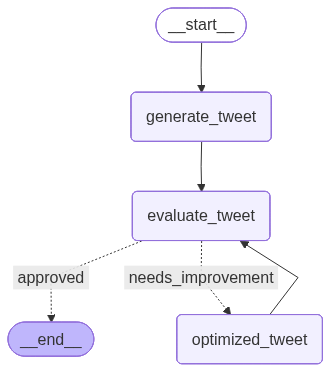

In [55]:
graph=StateGraph(TweetState)

graph.add_node('generate_tweet',generate_tweet)
graph.add_node('evaluate_tweet',evaluate_tweet)
graph.add_node('optimized_tweet',optimized_tweet)

graph.add_edge(START,'generate_tweet')
graph.add_edge('generate_tweet','evaluate_tweet')

graph.add_conditional_edges('evaluate_tweet',route_evaluation,{'approved':END,'needs_improvement':'optimized_tweet'})
graph.add_edge('optimized_tweet','evaluate_tweet')


workflow = graph.compile()
workflow


In [66]:
initial_state={
    "topic":"fadjksbav",
    "iteration":1,
    "max_iteration":5
}

result = workflow.invoke(initial_state)

In [67]:
result

{'topic': 'fadjksbav',
 'tweet': '"just spent 10 minutes trying to figure out what \'fadjksbav\' means, now my entire browser history is filled with \'fadjksbav\' and I\'m pretty sure I\'m now a walking, talking meme #fadjksbavlife"',
 'evaluation': 'approved',
 'feedback': "This tweet is a breath of fresh air, showcasing originality and humor. The relatable scenario of trying to decipher a mysterious term and ending up with a filled browser history is clever and amusing. The use of '#fadjksbavlife' adds a touch of irony and meme culture, making it scroll-stopping and potentially viral. The tweet is well-formed, concise, and effectively conveys the humor without relying on overused formats or ending with a deflating line. Overall, this tweet has a great balance of creativity, humor, and punchiness, making it worthy of approval.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"just spent 10 minutes trying to figure out what \'fadjksbav\' means, now my entire browser history 

In [68]:
for tweet in result['tweet_history']:
    print(tweet)

"just spent 10 minutes trying to figure out what 'fadjksbav' means, now my entire browser history is filled with 'fadjksbav' and I'm pretty sure I'm now a walking, talking meme #fadjksbavlife"
